In [ ]:
#import google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import tabela orders
import pandas as pd

path = "/content/drive/MyDrive/olist-analytics/data/"

orders = pd.read_csv(path + "olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
#agrupar por pedido
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")

order_items_grouped = order_items.groupby("order_id").agg({"price": "sum", "freight_value": "sum"}).reset_index()
order_items_grouped.head()
#

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


In [ ]:
#Join entre items e orders
df = orders.merge(order_items_grouped, on="order_id", how="left")

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72


In [ ]:
#num linhas em df
df.shape

(99441, 10)

In [ ]:
#check num linhas unicas
df["order_id"].nunique()

99441

In [ ]:
#Soma coluna preço de items
df["price"].sum()

np.float64(13591643.700000001)

In [ ]:
#Media coluna preço de items
df["price"].mean()

np.float64(137.75407637889447)

In [ ]:
#Converter data
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [ ]:
#Nova coluna - mês
df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M")

In [ ]:
#Agrupamento de preço por ano_mes para verificar a tendencia ao longo do tempo. "O negócio está crescendo de forma consistente?"
receita_mes = df.groupby("ano_mes")["price"]. sum().reset_index()
receita_mes

,ano_mes,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


Após crescimento inicial, o volume de receita passa a apresentar maior variabilidade, indicando possível efeito de sazonalidade ou estabilização de crescimento.

In [ ]:
#Tempo de entrega - conversão de datas
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

In [ ]:
#Variavel atrasos - booleano
df["atraso"] = df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]

In [ ]:
#Percentual de pedidos atrasados. "A empresa está cumprindo o que promete?"
df["atraso"].mean()

np.float64(0.07870998883760219)

In [ ]:
#Evolução do atraso no tempo
atraso_mes = df.groupby("ano_mes") ["atraso"].mean().reset_index()
atraso_mes

,ano_mes,atraso
0,2016-09,0.250000
1,2016-10,0.009259
2,2016-12,0.000000
3,2017-01,0.028750
4,2017-02,0.029775
5,2017-03,0.052946
6,2017-04,0.075291
7,2017-05,0.034595
8,2017-06,0.037288
9,2017-07,0.033035


<Axes: xlabel='ano_mes'>

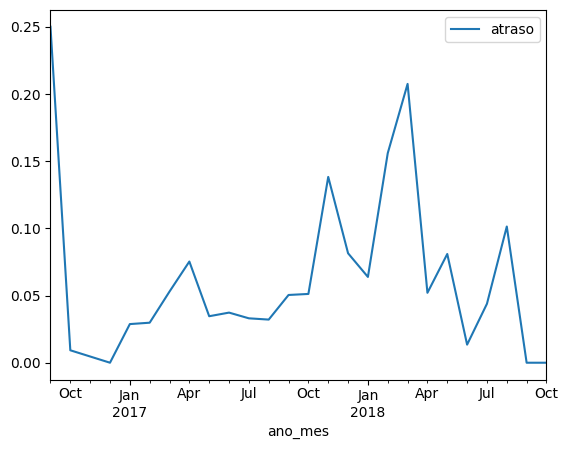

In [ ]:
atraso_mes.plot(x="ano_mes",y="atraso")

Apesar de taxa media de atraso se manter em niveis moderados (~8%), observa-se alta variabilidade ao longo do tempo, indicando instabilidade operacional em determinados períodos

In [ ]:
#Satisfação do cliente - trazer reviews
reviews = pd.read_csv (path + "olist_order_reviews_dataset.csv")

In [ ]:
#Join com a base principal trazendo os reviews
df = df.merge(reviews[["order_id","review_score"]], on="order_id", how="left")

In [ ]:
#Média de nota geral
df ["review_score"].mean()

np.float64(4.08642062404257)

In [ ]:
#Respondendo a pergunta: "Atraso impacta a nota?". Agrupando atraso, trazendo a media para false e true
df.groupby("atraso")["review_score"].mean()

,review_score
atraso,
False,4.214307
True,2.566550


Pedidos entregues com atraso apresentam queda significativa na avaliação dos clientes, evidenciando impacto direto da eficiência logística na satisfação.
Queda de 1,65 pontos, ou seja 30% da nota final.


In [ ]:
#Conectar crescimento com atraso
analise_mes = df.groupby("ano_mes").agg({
    "price": "sum",
    "atraso": "mean"
}).reset_index()

analise_mes

,ano_mes,price,atraso
0,2016-09,267.36,0.250000
1,2016-10,49634.35,0.009202
2,2016-12,10.90,0.000000
3,2017-01,121087.90,0.028501
4,2017-02,248563.02,0.029642
5,2017-03,376010.70,0.052651
6,2017-04,360738.17,0.075487
7,2017-05,509639.63,0.034252
8,2017-06,436550.89,0.037229
9,2017-07,501299.70,0.033432


In [ ]:
#Adicionar satisfação
analise_mes = df.groupby("ano_mes").agg({
    "price": "sum",
    "atraso": "mean",
    "review_score": "mean"
}).reset_index()
analise_mes

,ano_mes,price,atraso,review_score
0,2016-09,267.36,0.250000,1.000000
1,2016-10,49634.35,0.009202,3.570093
2,2016-12,10.90,0.000000,5.000000
3,2017-01,121087.90,0.028501,4.070263
4,2017-02,248563.02,0.029642,4.017455
5,2017-03,376010.70,0.052651,4.072496
6,2017-04,360738.17,0.075487,4.043860
7,2017-05,509639.63,0.034252,4.142587
8,2017-06,436550.89,0.037229,4.147692
9,2017-07,501299.70,0.033432,4.171131


1. Não há correlação direta consistente entre crescimento de receita e aumento de atrasos, indicando que outros fatores operacionais ou sazonais influenciam a eficiência logística
2. Meses com taxa de atraso superior a 10% apresentam queda relevante na avaliação média dos clientes, frequentemente abaixo de 4 pontos.
3. Observa-se concentração de pior desempenho operacional no início do ano, com aumento de atrasos e queda na satisfação, sugerindo possíveis gargalos logísticos pós-alta demanda do período anterior.

In [ ]:
#Validação - n. de pedidos
df.groupby("ano_mes")["order_id"].count().reset_index()

,ano_mes,order_id
0,2016-09,4
1,2016-10,326
2,2016-12,1
3,2017-01,807
4,2017-02,1788
5,2017-03,2697
6,2017-04,2411
7,2017-05,3737
8,2017-06,3277
9,2017-07,4068


In [ ]:
#Filtrar meses com pouco volume
pedidos_mes = df.groupby("ano_mes")["order_id"].count().reset_index()

meses_validos = pedidos_mes[pedidos_mes["order_id"] > 1000]["ano_mes"]

df_filtrado = df[df["ano_mes"].isin(meses_validos)]

In [ ]:
#Receita + atraso + satisfação por mês com base filtrada
analise_mes = df_filtrado.groupby("ano_mes").agg({
    "price": "sum",
    "atraso": "mean",
    "review_score": "mean"
}).reset_index()

In [ ]:
#Renomear colunas
analise_mes = analise_mes.rename(columns={
    "price": "receita",
    "atraso": "perc_atraso",
    "review_score": "nota_media"
})

In [ ]:
#Classificação de ano_mes
analise_mes.sort_values("ano_mes")

,ano_mes,receita,perc_atraso,nota_media
0,2017-02,248563.02,0.029642,4.017455
1,2017-03,376010.70,0.052651,4.072496
2,2017-04,360738.17,0.075487,4.043860
3,2017-05,509639.63,0.034252,4.142587
4,2017-06,436550.89,0.037229,4.147692
5,2017-07,501299.70,0.033432,4.171131
6,2017-08,578588.99,0.032236,4.236121
7,2017-09,626752.17,0.050104,4.188684
8,2017-10,667869.15,0.050815,4.123649
9,2017-11,1017758.83,0.138063,3.910937


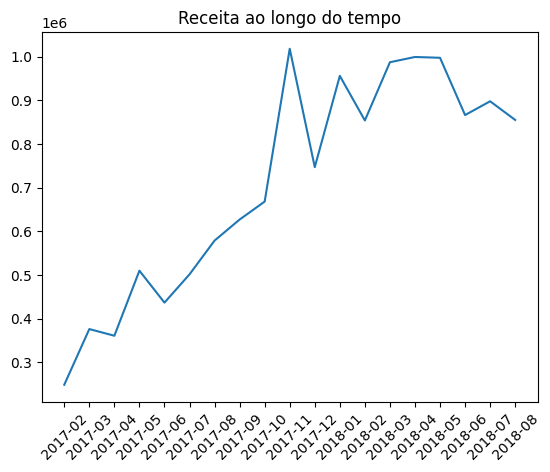

In [ ]:
#Grafico receita
import matplotlib.pyplot as plt

plt.figure()
plt.plot(analise_mes["ano_mes"].astype(str), analise_mes["receita"])
plt.xticks(rotation=45)
plt.title("Receita ao longo do tempo")
plt.show()

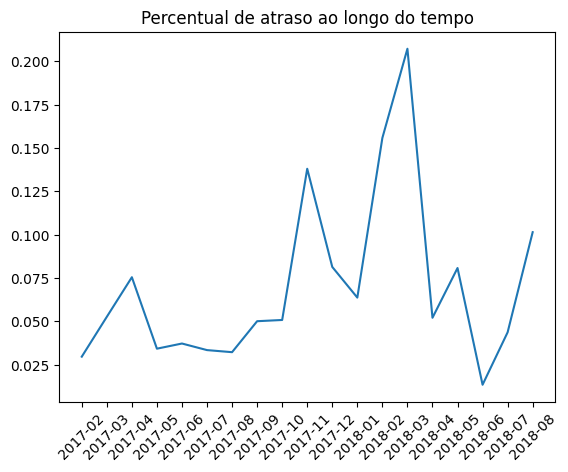

In [ ]:
#Grafico Atraso
plt.figure()
plt.plot(analise_mes["ano_mes"].astype(str), analise_mes["perc_atraso"])
plt.xticks(rotation=45)
plt.title("Percentual de atraso ao longo do tempo")
plt.show()

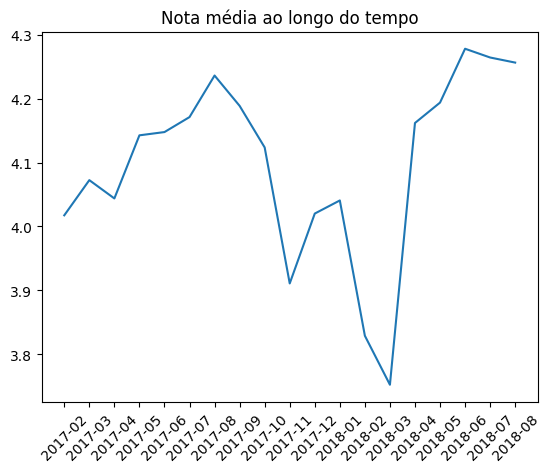

In [ ]:
#Grafico Satisfação
plt.figure()
plt.plot(analise_mes["ano_mes"].astype(str), analise_mes["nota_media"])
plt.xticks(rotation=45)
plt.title("Nota média ao longo do tempo")
plt.show()

In [ ]:
#% Atraso geral (corrigido com valores filtrados)
df_filtrado["atraso"].mean()

np.float64(0.07931481069267661)

In [ ]:
#Nota media geral (corrigida com valores filtrados)
df_filtrado["review_score"].mean()

np.float64(4.088782855162007)

In [ ]:
#Comparação atraso vs nota (corrigida com valores filtrados)
df_filtrado.groupby("atraso")["review_score"].mean()

,review_score
atraso,
False,4.217851
True,2.568656


In [ ]:
#Identificação de meses mais críticos (atrasos maiores que 10%)
analise_mes[analise_mes["perc_atraso"] > 0.10]

,ano_mes,receita,perc_atraso,nota_media
9,2017-11,1017758.83,0.138063,3.910937
12,2018-02,853591.21,0.155856,3.829091
13,2018-03,986867.05,0.207310,3.752470
18,2018-08,854760.45,0.101474,4.256359


In [ ]:
#Cruzamento entre atrasos maiores que 10% e nota
analise_mes[
    (analise_mes["perc_atraso"] > 0.10) &
    (analise_mes["nota_media"] < 4)
]

,ano_mes,receita,perc_atraso,nota_media
9,2017-11,1017758.83,0.138063,3.910937
12,2018-02,853591.21,0.155856,3.829091
13,2018-03,986867.05,0.207310,3.752470


O impacto negativo da logística não é constante, mas concentrado em períodos específicos, indicando falhas pontuais na operação.
O início de 2018 apresenta picos relevantes de atraso, com impacto direto na satisfação, caracterizando um período crítico da operação.
Recomendação:
1. Reforçar a capacidade logística em períodos críticos identificados (ex: início do ano), evitando degradação da experiência do cliente.
2. implementar monitoramento contínuo de SLA com alertas para períodos de aumento de atraso, permitindo atuação preventiva.
3. Criar mecanismos de priorização para pedidos com maior risco de atraso, reduzindo impacto direto na satisfação.


In [ ]:
#Carregando Customers
customers = pd.read_csv(path + "olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
#Verifica duplicidade em city
customers["customer_city"].nunique()

4119

In [ ]:
#Primeira letra maiuscula em city
customers["customer_city"] = customers["customer_city"].str.title()

In [ ]:
#Remover espaços extras em city
customers["customer_city"] = customers["customer_city"].str.strip()

In [ ]:
#Verifica duplicidade em city
customers["customer_city"].nunique()

4119

In [ ]:
#Criar coluna cidade-estado
customers["cidade_estado"] = customers["customer_city"] + " - " + customers["customer_state"]

In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,cidade_estado
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Franca,SP,Franca - SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,Sao Bernardo Do Campo,SP,Sao Bernardo Do Campo - SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,Sao Paulo,SP,Sao Paulo - SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,Mogi Das Cruzes,SP,Mogi Das Cruzes - SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,Campinas,SP,Campinas - SP


In [ ]:
df = df.merge(
    customers[["customer_id", "customer_zip_code_prefix", "customer_state", "customer_city", "cidade_estado"]],
    on="customer_id",
    how="left"
)

In [ ]:
pedidos_mes = df.groupby("ano_mes")["order_id"].count().reset_index()

meses_validos = pedidos_mes[pedidos_mes["order_id"] > 1000]["ano_mes"]

df_filtrado = df[df["ano_mes"].isin(meses_validos)].copy()

In [ ]:
df_filtrado

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,ano_mes,atraso,review_score,customer_zip_code_prefix,customer_state,customer_city,cidade_estado
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,2017-10,False,4.0,3149,SP,Sao Paulo,Sao Paulo - SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,2018-07,False,4.0,47813,BA,Barreiras,Barreiras - BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,2018-08,False,5.0,75265,GO,Vianopolis,Vianopolis - GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,2017-11,False,5.0,59296,RN,Sao Goncalo Do Amarante,Sao Goncalo Do Amarante - RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,2018-02,False,5.0,9195,SP,Santo Andre,Santo Andre - SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,72.00,13.08,2017-03,False,5.0,12209,SP,Sao Jose Dos Campos,Sao Jose Dos Campos - SP
99988,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,174.90,20.10,2018-02,False,4.0,11722,SP,Praia Grande,Praia Grande - SP
99989,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,205.99,65.02,2017-08,False,5.0,45920,BA,Nova Vicosa,Nova Vicosa - BA
99990,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,359.98,81.18,2018-01,False,2.0,28685,RJ,Japuiba,Japuiba - RJ


In [ ]:
#Criando a base de dados por estado
analise_estado = df_filtrado.groupby("customer_state").agg({
    "order_id": "count",
    "atraso": "mean",
    "review_score": "mean",
    "price": "sum"
}).reset_index()

In [ ]:
#Melhorar nomes
analise_estado = analise_estado.rename(columns={
    "order_id": "qtd_pedidos",
    "atraso": "perc_atraso",
    "review_score": "nota_media",
    "price": "receita"
})

In [ ]:
#Filtrar estados mais relevantes
analise_estado = analise_estado[analise_estado["qtd_pedidos"] > 500]
analise_estado

,customer_state,qtd_pedidos,perc_atraso,nota_media,receita
4,BA,3368,0.136580,3.859976,508332.71
5,CE,1322,0.148260,3.849200,225192.73
6,DF,2141,0.068660,4.070925,301787.77
7,ES,2027,0.120375,4.048000,272736.93
8,GO,2009,0.080637,4.038577,292256.71
9,MA,738,0.188347,3.758856,118521.75
10,MG,11551,0.055493,4.138337,1570228.89
11,MS,725,0.113103,4.117566,118068.71
12,MT,896,0.066964,4.120360,154436.80
13,PA,965,0.121244,3.842437,176115.99


In [ ]:
#Classificar atraso
analise_estado.sort_values("perc_atraso", ascending=False)

,customer_state,qtd_pedidos,perc_atraso,nota_media,receita
9,MA,738,0.188347,3.758856,118521.75
5,CE,1322,0.148260,3.849200,225192.73
4,BA,3368,0.136580,3.859976,508332.71
18,RJ,12771,0.130765,3.879153,1807530.40
13,PA,965,0.121244,3.842437,176115.99
7,ES,2027,0.120375,4.048000,272736.93
11,MS,725,0.113103,4.117566,118068.71
14,PB,534,0.106742,4.015152,114898.28
15,PE,1647,0.103825,4.008584,260548.06
23,SC,3608,0.096175,4.077654,513085.52


In [ ]:
#Identificar estados criticos
analise_estado[
    (analise_estado["perc_atraso"] > 0.10) &
    (analise_estado["nota_media"] < 4)
]

,customer_state,qtd_pedidos,perc_atraso,nota_media,receita
4,BA,3368,0.136580,3.859976,508332.71
5,CE,1322,0.148260,3.849200,225192.73
9,MA,738,0.188347,3.758856,118521.75
13,PA,965,0.121244,3.842437,176115.99
18,RJ,12771,0.130765,3.879153,1807530.40


In [ ]:
#Top estados por receita
analise_estado.sort_values("receita", ascending=False).head(10)

,customer_state,qtd_pedidos,perc_atraso,nota_media,receita
25,SP,41540,0.057342,4.176783,5172478.45
18,RJ,12771,0.130765,3.879153,1807530.40
10,MG,11551,0.055493,4.138337,1570228.89
22,RS,5424,0.070981,4.135505,737539.39
17,PR,4979,0.049408,4.179487,678409.47
23,SC,3608,0.096175,4.077654,513085.52
4,BA,3368,0.136580,3.859976,508332.71
6,DF,2141,0.068660,4.070925,301787.77
8,GO,2009,0.080637,4.038577,292256.71
7,ES,2027,0.120375,4.048000,272736.93


Apesar da expectativa de maior atraso em regiões mais distantes, o estado do Rio de Janeiro se destaca negativamente, apresentando alto percentual de atraso mesmo com elevada representatividade na receita, sugerindo gargalos operacionais não relacionados à distância geográfica.

In [ ]:
#Pergunta: RJ impacta nos periodos mais criticos?
df_filtrado[df_filtrado["customer_state"] == "RJ"].groupby("ano_mes")["atraso"].mean()

,atraso
ano_mes,
2017-02,0.035433
2017-03,0.047859
2017-04,0.076471
2017-05,0.032454
2017-06,0.036232
2017-07,0.034722
2017-08,0.031746
2017-09,0.056818
2017-10,0.080238


IDENTIFICANDO O PROBLEMA: RJ É RESPONSAVEL PELA MAIOR % DE ATRASOS GERAL?

In [ ]:
#Total de pedidos atrasados
total_atrasos = df_filtrado["atraso"].sum()

In [ ]:
#Total de pedidos atrasados no RJ
atrasos_rj = df_filtrado[
    (df_filtrado["customer_state"] == "RJ") &
    (df_filtrado["atraso"] == True)
].shape[0]

In [ ]:
#% RJ nos atrasos
perc_rj_atrasos = atrasos_rj / total_atrasos
perc_rj_atrasos

np.float64(0.2130373772164817)

In [ ]:
#% de pedidos rj
total_pedidos = df_filtrado.shape[0]

pedidos_rj = df_filtrado[df_filtrado["customer_state"] == "RJ"].shape[0]

perc_rj_pedidos = pedidos_rj / total_pedidos
perc_rj_pedidos

0.12921666632940082

In [ ]:
#Nota media RJ vs BR
df_filtrado.groupby("customer_state")["review_score"].mean().sort_values()

,review_score
customer_state,
RR,3.659091
MA,3.758856
AL,3.760976
SE,3.789474
PA,3.842437
CE,3.849200
BA,3.859976
RJ,3.879153
PI,3.906639


O estado do Rio de Janeiro apresenta participação desproporcional nos atrasos logísticos (21% dos atrasos vs 13% dos pedidos), impactando negativamente a satisfação do cliente e indicando um gargalo operacional relevante em uma das principais regiões de receita.

In [ ]:
df_filtrado.shape[0]

98834

In [ ]:
df_filtrado["order_id"].nunique()

98292

In [ ]:
df_pedidos = df_filtrado.groupby("order_id").agg({
    "price": "sum",
    "atraso": "max",
    "review_score": "mean",
    "customer_state": "first",
    "ano_mes": "first"
}).reset_index()

In [ ]:
df_filtrado["receita_total"] = df_filtrado["price"] + df_filtrado["freight_value"]

In [ ]:
analise_mes = df_filtrado.groupby("ano_mes").agg({
    "receita_total": "sum",
    "atraso": "mean",
    "review_score": "mean"
}).reset_index()

In [ ]:
analise_estado = df_filtrado.groupby("customer_state").agg({
    "receita_total": "sum",
    "atraso": "mean",
    "review_score": "mean",
    "order_id": "count"
}).reset_index()

In [ ]:
df_filtrado ["price"].sum()

np.float64(13480777.96)

In [ ]:
df_filtrado["lead_time"] = (
    pd.to_datetime(df_filtrado["order_delivered_customer_date"]) -
    pd.to_datetime(df_filtrado["order_purchase_timestamp"])
).dt.days

In [ ]:
df_filtrado.to_csv(
    "base_final.csv",
    index=False,
    sep=";",        # MUITO IMPORTANTE
    decimal=","     # MUITO IMPORTANTE
)

In [ ]:
from google.colab import files
files.download("base_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>